# Aula 06 — Classes e métodos para Economia e Finanças (POO prática)

**Semana 3 | Aula de 50 min | Referências: McKinney, *Python for Data Analysis* (2012), Apêndice A (seções *Functions Are Objects* e *Namespaces, Scope and Local Functions*); VanderPlas, *Python Data Science Handbook*, cap. 1.**

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Criar classes com `__init__`, atributos e métodos para entidades financeiras (`ProjetoInvestimento`, `Emprestimo`);
- Implementar `calcular_vpl()` e `payback()` como métodos que usam os dados do próprio objeto;
- Sobrescrever `__repr__` para gerar visualização executiva de uma linha (✅/❌, VPL, payback);
- Comparar vários projetos/objetos em uma lista (carteira) e ordenar por critério econômico;
- Decidir quando classe vale a pena — e quando funções + dicionário bastam.

## 1. Da função à classe: por que agrupar?

**Intuição econômica.** Na Aula 05 você chamava `vpl(taxa, fluxos)` passando os dados
toda vez. Um laudo real tem **um projeto**: pivô de irrigação com capex, fluxos e taxa
que **pertencem** a ele. Classe = dados + cálculos no mesmo pacote. Não é engenharia
de software — é higiene de consultoria: impossível calcular o VPL do pivô com os
fluxos do silo se cada objeto carrega os seus.

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

np.random.seed(42)  # reprodutibilidade

In [2]:
# Classe mínima: __init__ guarda dados; métodos calculam com eles
class ProjetoInvestimento:
    """Entidade de um projeto de investimento (capex + fluxos + taxa)."""

    def __init__(self, capex, fluxo_caixa, taxa_desconto):
        """capex em R$; fluxo_caixa = lista dos fluxos dos anos 1..n;
        taxa_desconto em decimal por ano (0.139 = 13,9% a.a.)."""
        self.capex = capex
        self.fluxo_caixa = list(fluxo_caixa)
        self.taxa_desconto = taxa_desconto

    def calcular_vpl(self):
        """VPL = -capex + soma dos fluxos descontados."""
        return -self.capex + sum(
            fc / (1 + self.taxa_desconto) ** t
            for t, fc in enumerate(self.fluxo_caixa, start=1)
        )

# O projeto do silo da Aula 05, agora como objeto
silo = ProjetoInvestimento(
    capex=850_000,
    fluxo_caixa=[280_000, 310_000, 290_000, 300_000, 260_000],
    taxa_desconto=0.139,          # Selic set/2026
)
print(f"VPL do silo: {brl(silo.calcular_vpl())}")

VPL do silo: R$ 144.919,77


Anatomia: `__init__` roda na criação (`ProjetoInvestimento(...)`); `self` é o próprio
objeto — todo método o recebe como 1º parâmetro, e você **não** o passa na chamada.
`silo.calcular_vpl` **sem** parênteses devolve o método, não o número.

**A classe não é mágica**: se você criar outro objeto com outros valores, o objeto
antigo continua com os dados com que nasceu — objetos são independentes.

## 2. O projeto real: pivô central de irrigação (Rio Verde–GO)

**Cenário.** Fazenda de 100 ha em Rio Verde quer um **pivô central** para não depender
de chuva na soja: capex **R$ 2.500.000** (equipamento + adução + energia). Com
irrigação, o ganho médio é ~40 sc/ha/ano (soja a ~R$ 145,60/sc: US$ 12,9/bu × câmbio
5,12); a receita incremental sustenta fluxos crescentes de 10 anos (maturação da
lavoura e preços). Taxa de desconto: **13,9% a.a.** (Selic set/2026 — o custo de
oportunidade do capital do sócio).

Pergunta do produtor: "vale o dinheiro? Em quantos anos volto ao ponto de partida?"

In [3]:
# O pivô como objeto da nossa classe
pivo = ProjetoInvestimento(
    capex=2_500_000,
    fluxo_caixa=[430_000, 470_000, 500_000, 520_000, 540_000,
                 550_000, 560_000, 570_000, 575_000, 580_000],  # anos 1..10
    taxa_desconto=0.139,
)

print(f"VPL do pivô: {brl(pivo.calcular_vpl())}")
print(f"Soma dos fluxos (sem desconto): {brl(sum(pivo.fluxo_caixa))}")

VPL do pivô: R$ 183.188,85
Soma dos fluxos (sem desconto): R$ 5.295.000,00


In [4]:
# Sensibilidade: mesmo projeto, três cenários de taxa
for tx in [0.12, 0.139, 0.16]:
    pivo.taxa_desconto = tx                # objetos são MUTÁVEIS
    print(f"taxa {tx:.1%} → VPL = {brl(pivo.calcular_vpl())}")

# restaura a taxa-base para o resto da aula
pivo.taxa_desconto = 0.139

taxa 12.0% → VPL = R$ 407.651,08
taxa 13.9% → VPL = R$ 183.188,85
taxa 16.0% → VPL = R$ -34.975,80


**Leitura executiva.** VPL positivo a 13,9% (viável), negativo a 16% (inviável) —
o projeto fica "na corda bamba" entre a Selic e a taxa exigida pelo investidor. É por
isso que a próxima seção calcula o payback: quanto tempo o caixa fica exposto.

## 3. `payback()`: quando o caixa volta?

Payback simples = menor T com soma acumulada ≥ capex (interpolando dentro do ano).
Payback **descontado** = idem com fluxos descontados — o que o credor realmente
pergunta ("quando esse dinheiro volta em valor de hoje?").

In [5]:
# payback() entra na classe: acumulador + interpolação linear
class ProjetoInvestimento:
    """Entidade de um projeto de investimento (capex + fluxos + taxa)."""

    def __init__(self, capex, fluxo_caixa, taxa_desconto):
        self.capex = capex
        self.fluxo_caixa = list(fluxo_caixa)
        self.taxa_desconto = taxa_desconto

    def calcular_vpl(self):
        return -self.capex + sum(
            fc / (1 + self.taxa_desconto) ** t
            for t, fc in enumerate(self.fluxo_caixa, start=1)
        )

    def payback(self, descontado=False):
        """Anos para recuperar o capex (float, interpolado).

        descontado=False → payback simples
        descontado=True  → payback descontado (fluxos a valor presente)
        Devolve None se os fluxos não recuperam o capex no horizonte.
        """
        acumulado = -self.capex
        for t, fc in enumerate(self.fluxo_caixa, start=1):
            fc_t = fc / (1 + self.taxa_desconto) ** t if descontado else fc
            if acumulado + fc_t >= 0:            # recupera dentro deste ano
                return (t - 1) + (-acumulado) / fc_t
            acumulado += fc_t
        return None                              # nunca recupera

# recria o pivô (a classe foi redefinida acima neste notebook)
pivo = ProjetoInvestimento(2_500_000,
                           [430_000, 470_000, 500_000, 520_000, 540_000,
                            550_000, 560_000, 570_000, 575_000, 580_000],
                           0.139)
print(f"Payback simples:    {pivo.payback():.2f} anos")
print(f"Payback descontado: {pivo.payback(descontado=True):.2f} anos")

Payback simples:    5.07 anos
Payback descontado: 8.86 anos


**5,07 vs 8,86 anos.** O desconto a 13,9% empurra a recuperação em quase 4 anos —
a diferença entre "viável no papel" e "viável dentro do risco do produtor". Num laudo,
os dois números aparecem juntos, sempre.

## 4. `__repr__`: o objeto como relatório de uma linha

Sem `__repr__`, o notebook mostra `<__main__.ProjetoInvestimento object at 0x...>` —
inútil para cliente. Sobrescrevendo, o print vira veredito.

In [6]:
# __repr__ responde a pergunta do cliente em uma linha
class ProjetoInvestimento:
    """Projeto de investimento com VPL, payback e repr executivo."""

    def __init__(self, capex, fluxo_caixa, taxa_desconto):
        self.capex = capex
        self.fluxo_caixa = list(fluxo_caixa)
        self.taxa_desconto = taxa_desconto

    def calcular_vpl(self):
        return -self.capex + sum(
            fc / (1 + self.taxa_desconto) ** t
            for t, fc in enumerate(self.fluxo_caixa, start=1)
        )

    def payback(self, descontado=False):
        acumulado = -self.capex
        for t, fc in enumerate(self.fluxo_caixa, start=1):
            fc_t = fc / (1 + self.taxa_desconto) ** t if descontado else fc
            if acumulado + fc_t >= 0:
                return (t - 1) + (-acumulado) / fc_t
            acumulado += fc_t
        return None

    def __repr__(self):
        vpl = self.calcular_vpl()
        veredito = "✅ viável" if vpl > 0 else "❌ inviável"
        pb = self.payback()
        pb_txt = f"{pb:.1f} anos" if pb is not None else "não recupera"
        return (f"ProjetoInvestimento(VPL={brl(vpl)}, "
                f"payback={pb_txt}) {veredito}")

pivo = ProjetoInvestimento(2_500_000,
                           [430_000, 470_000, 500_000, 520_000, 540_000,
                            550_000, 560_000, 570_000, 575_000, 580_000],
                           0.139)
pivo                       # última linha da célula usa __repr__

ProjetoInvestimento(VPL=R$ 183.188,85, payback=5.1 anos) ✅ viável

A partir de agora, **toda** classe da aula terá `__repr__` executivo — é POO aplicada
à comunicação: o objeto se apresenta com o número que decide o laudo.

## 5. Carteira: comparando projetos como objetos

O silo (Aula 05) e o pivô agora são dois objetos comparáveis — e um terceiro cenário
do pivô com taxa de 16% mostra como a mesma classe gera cenários.

In [7]:
# Os projetos da consultoria em uma lista de objetos
silo = ProjetoInvestimento(850_000,
                           [280_000, 310_000, 290_000, 300_000, 260_000],
                           0.139)
pivo = ProjetoInvestimento(2_500_000,
                           [430_000, 470_000, 500_000, 520_000, 540_000,
                            550_000, 560_000, 570_000, 575_000, 580_000],
                           0.139)
pivo_estressado = ProjetoInvestimento(2_500_000,
                                      [430_000, 470_000, 500_000, 520_000, 540_000,
                                       550_000, 560_000, 570_000, 575_000, 580_000],
                                      0.16)   # cenário com taxa de 16% a.a.

carteira = [silo, pivo, pivo_estressado]
for p in carteira:
    print(p)                                   # __repr__ de cada um

# ordenar por VPL: funções como argumentos (Aula 05 reaparece)
melhor = max(carteira, key=lambda p: p.calcular_vpl())
print(f"\nMelhor projeto por VPL: {melhor!r}")

ProjetoInvestimento(VPL=R$ 144.919,77, payback=2.9 anos) ✅ viável
ProjetoInvestimento(VPL=R$ 183.188,85, payback=5.1 anos) ✅ viável
ProjetoInvestimento(VPL=R$ -34.975,80, payback=5.1 anos) ❌ inviável

Melhor projeto por VPL: ProjetoInvestimento(VPL=R$ 183.188,85, payback=5.1 anos) ✅ viável


In [8]:
# Síntese para o laudo: DataFrame comparativo a partir dos objetos
resumo = pd.DataFrame({
    "projeto": ["Silo (grãos)", "Pivô @13,9%", "Pivô (16%)"],
    "capex": [p.capex for p in carteira],
    "vpl": [p.calcular_vpl() for p in carteira],
    "payback_anos": [p.payback() for p in carteira],
})
resumo["capex"] = resumo["capex"].map(brl)
resumo["vpl"] = resumo["vpl"].map(brl)
resumo

,projeto,capex,vpl,payback_anos
0,Silo (grãos),"R$ 850.000,00","R$ 144.919,77",2.896552
1,"Pivô @13,9%","R$ 2.500.000,00","R$ 183.188,85",5.072727
2,Pivô (16%),"R$ 2.500.000,00","R$ -34.975,80",5.072727


**Silos vs pivô**: o pivô tem VPL maior (R$ 183.188,85 vs R$ 144.919,77), mas o silo
recupera o caixa em ~2,9 anos contra ~5,1 do pivô. Se o produtor tem prazo curto ou
caixa apertado, silo; se tem horizonte de 10 anos e quer maximizar valor, pivô.
VPL não é critério único — e objetos tornam essa comparação de 3 linhas.

## 6. Segunda classe: `Emprestimo`

Um financiamento também é uma entidade: principal, taxa mensal, prazo. E o cliente
sempre pergunta: "quanto fica a parcela?" e "quanto devo se eu quitar no mês X?"

In [9]:
# Classe Emprestimo: pmt() e saldo_devedor(mes)
class Emprestimo:
    """Financiamento Price: principal, taxa mensal e prazo."""

    def __init__(self, principal, taxa_mensal, n_meses):
        self.principal = principal
        self.taxa_mensal = taxa_mensal
        self.n_meses = n_meses

    def pmt(self):
        """Parcela fixa (Price): PV·i/(1-(1+i)^-n)."""
        pv, i, n = self.principal, self.taxa_mensal, self.n_meses
        return pv * i / (1 - (1 + i) ** -n)

    def saldo_devedor(self, mes):
        """Saldo após o pagamento do mês dado (após k parcelas):

        Saldo_k = PV·(1+i)^k − PMT·[((1+i)^k − 1)/i]
        """
        pv, i = self.principal, self.taxa_mensal
        pmt = self.pmt()
        k = min(mes, self.n_meses)
        return pv * (1 + i) ** k - pmt * (((1 + i) ** k - 1) / i)

    def __repr__(self):
        juros = self.pmt() * self.n_meses - self.principal
        return (f"Emprestimo({brl(self.principal)} a {self.taxa_mensal:.2%} a.m., "
                f"{self.n_meses}× de {brl(self.pmt())}; juros {brl(juros)})")

# crédito-pessoa-jurídica típico: R$ 50 mil, 1,19% a.m., 24×
emprestimo = Emprestimo(50_000, 0.0119, 24)
emprestimo

Emprestimo(R$ 50.000,00 a 1.19% a.m., 24× de R$ 2.407,26; juros R$ 7.774,32)

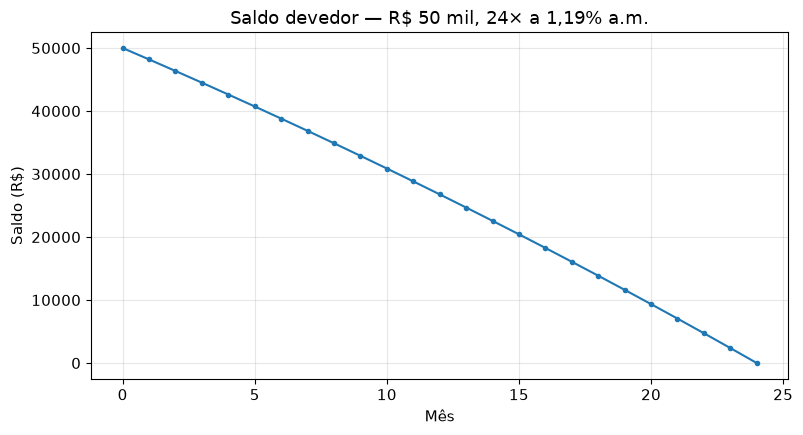

Parcela: R$ 2.407,26
Quitando após o mês 12, deve-se: R$ 26.771,49


In [10]:
# Saldo devedor: por que quitar antes "economiza" juros
meses = list(range(0, 25))
saldos = [emprestimo.saldo_devedor(m) for m in meses]

fig, ax = plt.subplots()
ax.plot(meses, saldos, marker="o", markersize=3)
ax.set_title("Saldo devedor — R$ 50 mil, 24× a 1,19% a.m.")
ax.set_xlabel("Mês")
ax.set_ylabel("Saldo (R$)")
plt.show()

print(f"Parcela: {brl(emprestimo.pmt())}")
print(f"Quitando após o mês 12, deve-se: {brl(emprestimo.saldo_devedor(12))}")

A curva mostra o que o cliente sempre estranha: no início, quase toda parcela é
juro — o saldo cai devagar no começo e rápido no fim. É o gráfico que justifica
(ou desaconselha) a quitação antecipada.

## 7. Terceira classe: `Titulo` (renda fixa com IR regressivo)

**Cenário.** O caixa da OIKOS parado rende 0 na conta; o gerente oferece um CDB que
paga 105% do CDI (CDI ≈ 14,15% a.a. → bruto ≈ 14,86% a.a.). O que muda a decisão é o
**IR regressivo** da renda fixa: 22,5% até 180 dias, 20% até 360, 17,5% até 720,
15% acima de 720 dias.

In [11]:
# Classe Titulo: rendimento bruto → IR regressivo → líquido
class Titulo:
    """Título de renda fixa com IR regressivo (tabela da RDB/CDB)."""

    # alíquotas por faixa de dias (tabela regressiva da renda fixa)
    TABELA_IR = [(180, 0.225), (360, 0.20), (720, 0.175), (float("inf"), 0.15)]

    def __init__(self, valor_aplicado, taxa_aa, prazo_dias):
        self.valor_aplicado = valor_aplicado
        self.taxa_aa = taxa_aa
        self.prazo_dias = prazo_dias

    def rendimento_bruto(self):
        """Valor futuro bruto: PV·(1+i)^(dias/365)."""
        return self.valor_aplicado * (1 + self.taxa_aa) ** (self.prazo_dias / 365)

    def ir_devido(self):
        """IR regressivo sobre o rendimento (não sobre o total)."""
        rendimento = self.rendimento_bruto() - self.valor_aplicado
        for limite, aliquota in self.TABELA_IR:
            if self.prazo_dias <= limite:
                return rendimento * aliquota
        return rendimento * 0.15

    def valor_liquido(self):
        return self.rendimento_bruto() - self.ir_devido()

    def __repr__(self):
        liq = self.valor_liquido()
        ganho = liq - self.valor_aplicado
        return (f"Titulo({brl(self.valor_aplicado)} por {self.prazo_dias} dias "
                f"a {self.taxa_aa:.2%} a.a. → líquido {brl(liq)}, "
                f"ganho {brl(ganho)})")

cdb = Titulo(10_000, 0.1486, 730)      # 2 anos: cai na alíquota de 15%
cdb

Titulo(R$ 10.000,00 por 730 dias a 14.86% a.a. → líquido R$ 12.713,90, ganho R$ 2.713,90)

In [12]:
# Comparação de prazos: a tabela regressiva em ação
prazos = [90, 180, 360, 720, 1080]
titulos = [Titulo(10_000, 0.1486, d) for d in prazos]

comparacao = pd.DataFrame({
    "prazo_dias": prazos,
    "liquido": [t.valor_liquido() for t in titulos],
    "ir": [t.ir_devido() for t in titulos],
})
comparacao["ganho_liquido"] = comparacao["liquido"] - 10_000
for col in ["ir", "liquido", "ganho_liquido"]:
    comparacao[col] = comparacao[col].map(brl)
comparacao

,prazo_dias,liquido,ir,ganho_liquido
0,90,"R$ 10.269,33","R$ 78,19","R$ 269,33"
1,180,"R$ 10.548,01","R$ 159,10","R$ 548,01"
2,360,"R$ 11.171,38","R$ 292,84","R$ 1.171,38"
3,720,"R$ 12.592,84","R$ 550,00","R$ 2.592,84"
4,1080,"R$ 14.307,16","R$ 760,09","R$ 4.307,16"


**Leitura executiva.** O ganho líquido **por dia** é maior após 720 dias (alíquota cai
de 17,5% para 15%): carregar o título além de 2 anos muda a decisão só por causa da
tabela do fisco — mesmo ganho bruto, mais líquido no bolso.

## 📝 Exercícios

### Exercício 1 — Método `tir()` na classe

Adicione à `ProjetoInvestimento` um método `tir()` que devolve a taxa que zera o VPL.
Dica: varra taxas com `np.linspace(-0.5, 1.0, 1501)`, calcule o VPL em cada uma e
interpole na troca de sinal (`np.interp`). Para o pivô, deve dar ≈ 15,6% a.a.

In [13]:
# EXERCÍCIO 1 — seu código aqui


In [14]:
# SOLUÇÃO 1 — TIR por varredura + interpolação na troca de sinal
def tir(self):
    """TIR aproximada: varre taxas e interpola onde o VPL troca de sinal."""
    taxas = np.linspace(-0.5, 1.0, 1501)
    vpls = np.array([
        -self.capex + sum(
            fc / (1 + tx) ** t for t, fc in enumerate(self.fluxo_caixa, start=1)
        )
        for tx in taxas
    ])
    # primeiro índice em que o VPL cruza de positivo para não-positivo
    cruza = np.where((vpls[:-1] > 0) & (vpls[1:] <= 0))[0]
    if len(cruza) == 0:
        return None
    k = cruza[0]
    return float(np.interp(0.0, [vpls[k + 1], vpls[k]], [taxas[k + 1], taxas[k]]))

ProjetoInvestimento.tir = tir     # "colar" o método na classe existente

print(f"TIR do pivô: {pivo.tir():.2%} a.a.  (taxa exigida: 13,9%)")
print(f"TIR do silo: {silo.tir():.2%} a.a.")

TIR do pivô: 15.64% a.a.  (taxa exigida: 13,9%)
TIR do silo: 20.84% a.a.


**Confira**: TIR do pivô ≈ 15,64% > 13,9% (VPL positivo, coerente) e < 16%
(o cenário estressado tinha VPL negativo). A TIR é a taxa que zera o VPL — nunca
confundir com a taxa de desconto.

### Exercício 2 — O silo como objeto + comparação

Recrie o projeto do silo da Aula 05 (capex R$ 850.000; fluxos [280k, 310k, 290k, 300k,
260k]; taxa 13,9%) como `ProjetoInvestimento` e compare com o pivô: VPL e payback de
cada um. Qual você recomendaria a um produtor com caixa apertado?

In [15]:
# EXERCÍCIO 2 — seu código aqui


In [16]:
# SOLUÇÃO 2 — silo como objeto e a comparação executiva
silo_ex = ProjetoInvestimento(850_000,
                              [280_000, 310_000, 290_000, 300_000, 260_000],
                              0.139)
for p in [silo_ex, pivo]:
    print(f"{p!r}  | payback descontado: {p.payback(descontado=True):.2f} anos")

if silo_ex.calcular_vpl() < pivo.calcular_vpl():
    print("\nSilo: menor VPL, mas recupera o caixa ~2 anos antes — "
          "melhor para quem tem caixa apertado.")

ProjetoInvestimento(VPL=R$ 144.919,77, payback=2.9 anos) ✅ viável  | payback descontado: 3.95 anos
ProjetoInvestimento(VPL=R$ 183.188,85, payback=5.1 anos) ✅ viável  | payback descontado: 8.86 anos

Silo: menor VPL, mas recupera o caixa ~2 anos antes — melhor para quem tem caixa apertado.


### Exercício 3 — `Emprestimo` com carência

Um cliente pede **3 meses de carência** no empréstimo da aula: paga apenas juros
(i·PV) nos 3 primeiros meses e depois amortiza em 21 parcelas sobre o principal
integral. Adicione o parâmetro `carencia=0` ao `__init__` e ajuste `pmt()`.
Compare parcela e juros totais com e sem carência.

In [17]:
# EXERCÍCIO 3 — seu código aqui


In [18]:
# SOLUÇÃO 3 — carência: só juros no início, PMT sobre o prazo restante
class EmprestimoComCarencia(Emprestimo):
    """Emprestimo com carência: nos primeiros meses paga só juros i·PV."""

    def __init__(self, principal, taxa_mensal, n_meses, carencia=0):
        super().__init__(principal, taxa_mensal, n_meses)
        self.carencia = carencia

    def pmt(self):
        """Parcela após a carência: PV amortizado em (n - carencia) meses."""
        pv, i = self.principal, self.taxa_mensal
        n_restante = self.n_meses - self.carencia
        return pv * i / (1 - (1 + i) ** -n_restante)

    def __repr__(self):
        juros = (self.carencia * self.principal * self.taxa_mensal
                 + self.pmt() * (self.n_meses - self.carencia) - self.principal)
        return (f"EmprestimoComCarencia({brl(self.principal)}, "
                f"{self.carencia} meses de carência, "
                f"{self.n_meses - self.carencia}× de {brl(self.pmt())}; "
                f"juros {brl(juros)})")

com_carencia = EmprestimoComCarencia(50_000, 0.0119, 24, carencia=3)
print(f"Sem carência:  {emprestimo!r}")
print(f"Com carência:  {com_carencia!r}")

Sem carência:  Emprestimo(R$ 50.000,00 a 1.19% a.m., 24× de R$ 2.407,26; juros R$ 7.774,32)
Com carência:  EmprestimoComCarencia(R$ 50.000,00, 3 meses de carência, 21× de R$ 2.704,90; juros R$ 8.587,82)


**Para o cliente**: a carência deixa o caixa mais folgado nos 3 primeiros meses
(apenas R$ 595,00 de juros/mês) mas encarece o crédito em R$ 813,50 no total —
alivia hoje, cobra depois. Quantificar esse trade-off é trabalho de economista.

### Exercício 4 — `Carteira` de projetos (composição)

Crie uma classe `Carteira` com atributo `projetos` (lista de `ProjetoInvestimento`)
e métodos `vpl_total()` e `melhor_projeto()`. Instancie com `silo`, `pivo` e
`pivo_estressado` e mostre o VPL total e o melhor projeto.

In [19]:
# EXERCÍCIO 4 — seu código aqui


In [20]:
# SOLUÇÃO 4 — composição: objeto contendo objetos
class Carteira:
    """Conjunto de projetos de investimento."""

    def __init__(self, projetos):
        self.projetos = list(projetos)

    def vpl_total(self):
        return sum(p.calcular_vpl() for p in self.projetos)

    def melhor_projeto(self):
        return max(self.projetos, key=lambda p: p.calcular_vpl())

    def __repr__(self):
        linhas = "\n".join(f"  {p!r}" for p in self.projetos)
        return f"Carteira (VPL total {brl(self.vpl_total())}):\n{linhas}"

carteira_ex = Carteira([silo, pivo, pivo_estressado])
print(carteira_ex)
print(f"\nMelhor projeto: {carteira_ex.melhor_projeto()!r}")

Carteira (VPL total R$ 293.132,81):
  ProjetoInvestimento(VPL=R$ 144.919,77, payback=2.9 anos) ✅ viável
  ProjetoInvestimento(VPL=R$ 183.188,85, payback=5.1 anos) ✅ viável
  ProjetoInvestimento(VPL=R$ -34.975,80, payback=5.1 anos) ❌ inviável

Melhor projeto: ProjetoInvestimento(VPL=R$ 183.188,85, payback=5.1 anos) ✅ viável


## 📌 Resumo & para casa

- **Classe** = dados (atributos) + cálculos (métodos) num pacote com identidade: `ProjetoInvestimento`, `Emprestimo`, `Titulo`.
- `__init__` recebe os dados na criação; `self` carrega o próprio objeto para dentro dos métodos.
- `calcular_vpl()` e `payback()` viram métodos: os números viajam com o projeto, impossível misturar projetos.
- `__repr__` é o relatório executivo de uma linha — ✅/❌, VPL, payback.
- `Emprestimo.saldo_devedor()` explica quitação antecipada; `Titulo` mostra o efeito do IR regressivo na decisão de prazo.
- Composição (`Carteira` contendo projetos) é o caminho natural para dados tabulares — a Aula 15 refaz tudo isso com pandas.

**Para casa**: acrescente à `Emprestimo` um método `tabela_pagamento()` (DataFrame
estilo Price, como na Aula 05) e à `Titulo` um método `rendimento_liquido_aa()`
(ganho líquido anualizado). Compare no papel antes de rodar.

**Referências KB**:
`kb/01_mckinney_python_for_data_analysis/15_appendix-python-language-essentials.md`
(seções *Functions Are Objects* e *Namespaces, Scope, and Local Functions*);
`kb/02_vanderplas_python_data_science_handbook/04_chapter-1.md`.
**Próximas aulas**: Aula 14 (DRE/balanço) e Aula 15 (VPL/TIR/amortização com pandas —
`kb/01_mckinney_python_for_data_analysis/13_chapter-11.md`).